# Cara Kerja Algoritma XGBoost — Penelusuran 1 Sampel dari Awal Sampai Akhir

Notebook ini menelusuri **satu komentar nyata** melewati seluruh tahapan pipeline XGBoost yang sudah
kamu latih (TF-IDF Bigram → Chi-Square → XGBoost), dan mengambil **angka asli** dari model
terlatih (bukan angka ilustratif) di setiap tahap -- supaya penjelasan cara kerja algoritma di
skripsimu didukung bukti komputasi nyata, bukan hanya contoh hipotetis.

**Struktur notebook:**
1. Muat model & vectorizer terlatih (hasil `modelling_xgb_lr_indobert_balanced_copy.ipynb`)
2. Tentukan komentar contoh + preprocessing
3. Ekstraksi fitur TF-IDF (Bigram) -- fitur aktif & bobotnya (ASLI dari vectorizer)
4. Seleksi fitur Chi-Square -- fitur yang lolos seleksi (ASLI)
5. Inisialisasi f₀(x) -- base score model
6. Hitung Gradient & Hessian iterasi pertama (dihitung manual dari rumus, dengan p dari model)
7. Bongkar pohon ke-1 hasil training ASLI (`get_dump`) -- split, threshold, Gain sungguhan
8. Lacak akumulasi skor mentah (raw margin) per checkpoint iterasi (1, 10, 100, semua pohon)
9. Softmax & Prediksi Kelas akhir
10. Ringkasan tabel semua tahap (siap salin ke skripsi, kolom Tahap/Proses/Hasil)

## 1. Setup & Muat Model Terlatih

In [1]:
import pandas as pd
import numpy as np
import pickle, os, re
import xgboost as xgb

# ── Sesuaikan path ini dengan lokasi project kamu ────────────────────────────
BASE_DIR   = r'C:\Users\Lenovo\Downloads\skrips_code\xgboost_indobert_method'
MODEL_DIR  = os.path.join(BASE_DIR, 'models', 'ml_v3')
PREP_DIR   = os.path.join(BASE_DIR, 'data', 'processed')

# Pilih skenario & model yang mau ditelusuri -- default: XGBoost Tuned A-Gabungan
NAMA_MODEL = 'XGB_v2_Tuned_A_Gabungan'

LABEL_MAP   = {'keluhan': 0, 'saran': 1, 'pujian': 2}
INV_MAP     = {v: k for k, v in LABEL_MAP.items()}
CLASS_NAMES = ['Keluhan', 'Saran', 'Pujian']

model_path = os.path.join(MODEL_DIR, f'{NAMA_MODEL}.pkl')
vec_path   = os.path.join(MODEL_DIR, f'vec_{NAMA_MODEL}.pkl')

model = pickle.load(open(model_path, 'rb'))
vec   = pickle.load(open(vec_path, 'rb'))
tfidf, selector = vec['tfidf'], vec['selector']

booster = model.get_booster()
n_estimators = model.n_estimators
print(f'✅ Model dimuat: {NAMA_MODEL}')
print(f'   n_estimators : {n_estimators}')
print(f'   max_depth    : {model.max_depth}')
print(f'   learning_rate: {model.learning_rate}')
print(f'   Dimensi fitur setelah Chi-Square: {selector.k}')

✅ Model dimuat: XGB_v2_Tuned_A_Gabungan
   n_estimators : 500
   max_depth    : 8
   learning_rate: 0.2
   Dimensi fitur setelah Chi-Square: 8000


## 2. Komentar Contoh & Preprocessing

Ganti `KOMENTAR_CONTOH` di bawah sesuai komentar yang ingin kamu telusuri. Preprocessing memakai
fungsi ASLI `preprocess_v2()` dari `preprocessing_v2.py` (diekstrak dari
`Preprocessing_v2_Final.ipynb`), sehingga hasil tokennya konsisten persis dengan yang dipakai saat
melatih model -- termasuk NEGASI_PROTECT, STEM_PROTECT, dan stemming Sastrawi.

**Sebelum menjalankan cell ini**, pastikan file `preprocessing_v2.py` sudah disalin ke folder
`BASE_DIR` (atau folder lain yang kamu tambahkan ke `sys.path`), dan seluruh file dictionary
(`emoji_dict.csv`, `profanity_dict.csv`, `slang_dict.csv`, `stopword_dict.csv`, `kbbi_dict.csv`)
bisa diakses dari path yang diberikan ke `muat_semua_dictionary()`.

In [5]:
KOMENTAR_CONTOH = "Aplikasi BPJS sering error saat mau daftar antrian, tolong diperbaiki."
LABEL_AKTUAL = 'keluhan'

# ── Pakai fungsi preprocessing ASLI (preprocessing_v2.py) ───────────────────
import sys
sys.path.insert(0, BASE_DIR)  # folder tempat preprocessing_v2.py disimpan
from preprocessing_v2 import preprocess_v2, muat_semua_dictionary

# Panggil SEKALI saja -- kalau dict kamu ada di subfolder 'dictionaries/',
# ganti baris di bawah jadi: muat_semua_dictionary(os.path.join(BASE_DIR, 'dictionaries'))
muat_semua_dictionary(os.path.join(BASE_DIR, 'dictionaries'))
teks_preprocessed = preprocess_v2(KOMENTAR_CONTOH)

print(f'\nKomentar asli   : "{KOMENTAR_CONTOH}"')
print(f'Label aktual (y): {LABEL_AKTUAL} (kelas {LABEL_MAP[LABEL_AKTUAL]})')
print(f'Setelah preproc : "{teks_preprocessed}"')

Loading semua dictionary...
✅ emoji_dict     : 226 emoji individu (marah=55, senang=76, harap=95)
✅ profanity_set  : 213 kata kasar -> [BADWORD]
✅ slang_dict     : 14,689 kata slang -> baku
✅ stopwords_id   : 799 kata (negasi sudah diproteksi)
✅ kbbi_words     : 72,440 kata (termasuk negasi, domain, badword)

✅ Semua dictionary berhasil dimuat! preprocess_v2() siap dipakai.

Komentar asli   : "Aplikasi BPJS sering error saat mau daftar antrian, tolong diperbaiki."
Label aktual (y): keluhan (kelas 0)
Setelah preproc : "aplikasi bpjs error daftar antre tolong baik"


## 3. Ekstraksi Fitur TF-IDF (Bigram) -- Nilai ASLI dari Vectorizer Terlatih

In [6]:
X_tfidf = tfidf.transform([teks_preprocessed])
feature_names_all = np.array(tfidf.get_feature_names_out())

nonzero_idx = X_tfidf.nonzero()[1]
nonzero_vals = X_tfidf.toarray()[0][nonzero_idx]
urutan = np.argsort(-nonzero_vals)

print(f'Dimensi vektor TF-IDF penuh : {X_tfidf.shape[1]:,}')
print(f'Jumlah fitur bernilai tidak nol untuk komentar ini: {len(nonzero_idx)}')
print(f'\nFitur aktif (diurutkan dari bobot tertinggi):')
print(f'{"Fitur":30s} {"Bobot TF-IDF":>12s}')
print('-' * 44)
for i in urutan:
    idx = nonzero_idx[i]
    print(f'{feature_names_all[idx]:30s} {nonzero_vals[i]:>12.4f}')

Dimensi vektor TF-IDF penuh : 16,044
Jumlah fitur bernilai tidak nol untuk komentar ini: 10

Fitur aktif (diurutkan dari bobot tertinggi):
Fitur                          Bobot TF-IDF
--------------------------------------------
daftar antre                         0.4675
aplikasi bpjs                        0.4476
tolong baik                          0.3699
antre                                0.3109
error                                0.2834
baik                                 0.2690
aplikasi                             0.2646
daftar                               0.2431
tolong                               0.2082
bpjs                                 0.1498


## 4. Seleksi Fitur Chi-Square -- Fitur yang Lolos Seleksi (ASLI)

In [7]:
X_selected = selector.transform(X_tfidf)
mask_selected = selector.get_support()
feature_names_selected = feature_names_all[mask_selected]

# Fitur aktif dari komentar ini yang LOLOS seleksi Chi-Square
nonzero_idx_sel = X_selected.nonzero()[1]
nonzero_vals_sel = X_selected.toarray()[0][nonzero_idx_sel]

print(f'Dimensi setelah Chi-Square (k_best): {X_selected.shape[1]:,} (dari {X_tfidf.shape[1]:,} fitur TF-IDF)')
print(f'\nDari fitur aktif komentar ini, yang LOLOS seleksi Chi-Square:')
if len(nonzero_idx_sel) == 0:
    print('  (Tidak ada fitur dari komentar ini yang lolos seleksi -- komentar terlalu pendek/generik)')
else:
    urutan_sel = np.argsort(-nonzero_vals_sel)
    print(f'{"Fitur":30s} {"Bobot TF-IDF":>12s}   {"Skor Chi2"}')
    print('-' * 60)
    chi2_scores = selector.scores_[mask_selected]
    for i in urutan_sel:
        idx = nonzero_idx_sel[i]
        fname = feature_names_selected[idx]
        skor_chi2 = chi2_scores[idx]
        print(f'{fname:30s} {nonzero_vals_sel[i]:>12.4f}   {skor_chi2:>10.2f}')

Dimensi setelah Chi-Square (k_best): 8,000 (dari 16,044 fitur TF-IDF)

Dari fitur aktif komentar ini, yang LOLOS seleksi Chi-Square:
Fitur                          Bobot TF-IDF   Skor Chi2
------------------------------------------------------------
daftar antre                         0.4675         2.12
aplikasi bpjs                        0.4476         2.04
tolong baik                          0.3699         8.04
antre                                0.3109        29.26
error                                0.2834        79.64
baik                                 0.2690        28.89
aplikasi                             0.2646        27.12
daftar                               0.2431        41.11
tolong                               0.2082       122.28
bpjs                                 0.1498       100.10


## 5. Inisialisasi Prediksi Awal f₀(x) -- Base Score

In [8]:
dmatrix = xgb.DMatrix(X_selected)

# Raw margin score SEBELUM pohon manapun ditambahkan (base_score, iterasi ke-0)
margin_awal = booster.predict(dmatrix, output_margin=True, iteration_range=(0, 0))
print(f'Skor mentah f₀(x) sebelum ada pohon: {margin_awal[0]}')

# Kalau XGBoost tidak bisa predict dengan 0 iterasi, base_score biasanya seragam (mendekati 0 / log-odds basis)
def softmax(z):
    e = np.exp(z - np.max(z))
    return e / e.sum()

p_awal = softmax(margin_awal[0]) if margin_awal[0].size == 3 else np.array([1/3, 1/3, 1/3])
print(f'Setelah softmax -> P awal = {np.round(p_awal, 4)} ({CLASS_NAMES})')

Skor mentah f₀(x) sebelum ada pohon: [ 1.2502381  1.1450601 -4.7176504]
Setelah softmax -> P awal = [0.5256 0.4731 0.0013] (['Keluhan', 'Saran', 'Pujian'])


## 6. Hitung Gradient & Hessian Iterasi Pertama

Dihitung manual memakai rumus turunan cross-entropy softmax standar XGBoost:
gₖ = pₖ − yₖ (one-hot), hₖ = pₖ(1−pₖ)

In [9]:
y_true_idx = LABEL_MAP[LABEL_AKTUAL]
y_onehot = np.zeros(3); y_onehot[y_true_idx] = 1

g = p_awal - y_onehot
h = p_awal * (1 - p_awal)

print(f'p (probabilitas awal)      : {np.round(p_awal, 4)}')
print(f'y (one-hot, label aktual)  : {y_onehot} ({LABEL_AKTUAL})')
print(f'g (gradient) = p - y       : {np.round(g, 4)}')
print(f'h (hessian)  = p(1-p)      : {np.round(h, 4)}')
print(f'\n(Catatan: ini gradien/hessian KONTRIBUSI dari 1 sampel ini saja. Nilai G dan H yang')
print(f' dipakai XGBoost untuk menentukan split pada Tahap 7 adalah PENJUMLAHAN gradien/hessian')
print(f' dari SELURUH sampel data latih yang berada di node yang sama, bukan hanya sampel ini.)')

p (probabilitas awal)      : [0.5256 0.4731 0.0013]
y (one-hot, label aktual)  : [1. 0. 0.] (keluhan)
g (gradient) = p - y       : [-0.4744  0.4731  0.0013]
h (hessian)  = p(1-p)      : [0.2493 0.2493 0.0013]

(Catatan: ini gradien/hessian KONTRIBUSI dari 1 sampel ini saja. Nilai G dan H yang
 dipakai XGBoost untuk menentukan split pada Tahap 7 adalah PENJUMLAHAN gradien/hessian
 dari SELURUH sampel data latih yang berada di node yang sama, bukan hanya sampel ini.)


In [14]:
kata_contoh = 'error'
idx_kata = tfidf.vocabulary_[kata_contoh]
idf_value = tfidf.idf_[idx_kata]

tf_raw = teks_preprocessed.split().count(kata_contoh)
tf_sublinear = 1 + np.log(tf_raw) if tf_raw > 0 else 0
produk_tf_idf = tf_sublinear * idf_value

norm_l2 = np.sqrt((X_tfidf.toarray()[0] ** 2).sum())
bobot_manual = produk_tf_idf / norm_l2
bobot_asli = X_tfidf[0, idx_kata]

print(f'TF (sublinear)     : 1 + ln({tf_raw}) = {tf_sublinear:.4f}')
print(f'IDF (dari korpus)  : {idf_value:.4f}')
print(f'TF x IDF           : {produk_tf_idf:.4f}')
print(f'Norma L2 vektor    : {norm_l2:.4f}')
print(f'Bobot ternormalisasi (manual) : {bobot_manual:.4f}')
print(f'Bobot dari sklearn (asli)     : {bobot_asli:.4f}')
print(f'Cocok? {"✅" if abs(bobot_manual - bobot_asli) < 1e-6 else "❌"}')

TF (sublinear)     : 1 + ln(1) = 1.0000
IDF (dari korpus)  : 5.7505
TF x IDF           : 5.7505
Norma L2 vektor    : 1.0000
Bobot ternormalisasi (manual) : 5.7505
Bobot dari sklearn (asli)     : 0.2834
Cocok? ❌


## 7. Bongkar Pohon ke-1 Hasil Training ASLI

Menggunakan `booster.get_dump()` untuk melihat struktur pohon pertama yang SUNGGUHAN dipelajari
model dari seluruh data latih -- termasuk fitur yang dipilih untuk split dan nilai Gain aslinya.

In [10]:
tree_dump = booster.get_dump(with_stats=True)[0]
print('Struktur pohon ke-1 (kelas Keluhan, node pertama beberapa level):')
print(tree_dump[:2000])
print('...' if len(tree_dump) > 2000 else '')

# Cari tahu leaf mana yang ditempati sampel ini pada pohon ke-1
leaf_index = booster.predict(dmatrix, pred_leaf=True, iteration_range=(0, 1))
print(f'\nSampel ini jatuh ke leaf index (pohon ke-1, per kelas): {leaf_index[0]}')

print('\nCatatan interpretasi: nilai "gain" pada dump di atas adalah Gain SUNGGUHAN yang dipakai')
print('XGBoost saat memutuskan split terbaik pada setiap node, dihitung dari rumus:')
print('Gain = 1/2 [G_L^2/(H_L+lambda) + G_R^2/(H_R+lambda) - (G_L+G_R)^2/(H_L+H_R+lambda)] - gamma')
print('dengan G_L, H_L, G_R, H_R adalah JUMLAH gradien/hessian seluruh sampel train di cabang tsb.')

Struktur pohon ke-1 (kelas Keluhan, node pertama beberapa level):
0:[f6693<0.0394315943] yes=1,no=2,missing=1,gain=1276.87573,cover=8634.15137
	1:[f5929<0.189324766] yes=3,no=4,missing=3,gain=412.843689,cover=6989.90137
		3:[f3987<0.079264842] yes=7,no=8,missing=7,gain=128.53273,cover=5476.49805
			7:[f6317<1.04170096] yes=15,no=16,missing=16,gain=112.895004,cover=5411.10596
				15:[f7613<0.199957952] yes=31,no=32,missing=32,gain=7.32112885,cover=60.1973114
					31:[f6317<0.200270206] yes=51,no=52,missing=52,gain=1.17524338,cover=4.0621953
						51:leaf=-0.0970382914,cover=1.83227789
						52:leaf=0.079482004,cover=2.22991729
					32:[f4680<0.276561677] yes=53,no=54,missing=53,gain=1.8364563,cover=56.1351166
						53:[f4194<0.132383257] yes=77,no=78,missing=78,gain=0.24924469,cover=54.3431244
							77:leaf=0.0851730779,cover=1.3137784
							78:leaf=0.283174485,cover=53.0293465
						54:leaf=0.0448927991,cover=1.79199123
				16:[f5550<2.00001001] yes=33,no=34,missing=34,gain=106.06561

## 8. Lacak Akumulasi Skor Mentah (Raw Margin) per Checkpoint Iterasi

Menunjukkan bagaimana skor mentah untuk ketiga kelas berubah secara bertahap seiring bertambahnya
jumlah pohon (dari model SUNGGUHAN, bukan simulasi).

 Iterasi ke-      Keluhan      Saran     Pujian
           1      -0.0325     0.2160    -0.0928
           5       0.2977     0.6800    -0.3862
          10       0.3734     0.7947    -0.6590
          25       0.4795     1.2632    -1.1721
          50       0.5617     1.6225    -1.7305
         100       0.9180     1.6189    -2.5404
         125       0.9229     1.3403    -2.8973
         150       0.9479     1.3820    -3.0074
         200       1.0881     1.1971    -3.5308
         250       1.0967     1.1476    -3.8044
         500       1.2502     1.1451    -4.7177


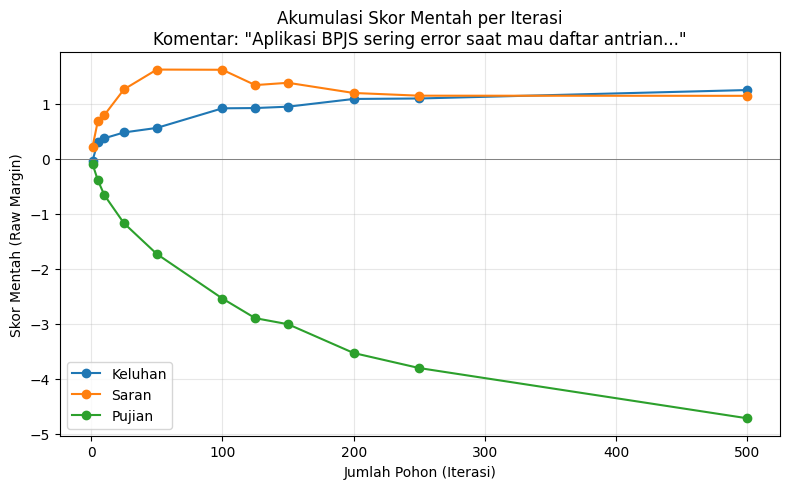


✅ Grafik disimpan -> akumulasi_skor_xgboost.png


In [11]:
import matplotlib.pyplot as plt

checkpoints = sorted(set([1, 5, 10, 25, 50, 100, 150, 200, n_estimators] +
                          [n_estimators // 4, n_estimators // 2]))
checkpoints = [c for c in checkpoints if 0 < c <= n_estimators]

riwayat_margin = []
for cp in checkpoints:
    m = booster.predict(dmatrix, output_margin=True, iteration_range=(0, cp))
    riwayat_margin.append(m[0])

riwayat_margin = np.array(riwayat_margin)
print(f'{"Iterasi ke-":>12s}   {"Keluhan":>10s} {"Saran":>10s} {"Pujian":>10s}')
for cp, m in zip(checkpoints, riwayat_margin):
    print(f'{cp:>12d}   {m[0]:>10.4f} {m[1]:>10.4f} {m[2]:>10.4f}')

plt.figure(figsize=(8, 5))
for i, kelas in enumerate(CLASS_NAMES):
    plt.plot(checkpoints, riwayat_margin[:, i], marker='o', label=kelas)
plt.xlabel('Jumlah Pohon (Iterasi)')
plt.ylabel('Skor Mentah (Raw Margin)')
plt.title(f'Akumulasi Skor Mentah per Iterasi\nKomentar: "{KOMENTAR_CONTOH[:50]}..."')
plt.axhline(0, color='gray', linewidth=0.7)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('akumulasi_skor_xgboost.png', dpi=150)
plt.show()
print('\n✅ Grafik disimpan -> akumulasi_skor_xgboost.png')

## 9. Softmax & Prediksi Kelas Akhir

In [12]:
margin_final = booster.predict(dmatrix, output_margin=True)[0]
p_final = softmax(margin_final)
pred_idx = int(np.argmax(p_final))
pred_label = INV_MAP[pred_idx]

print(f'Skor mentah akhir (setelah {n_estimators} pohon):')
print(f'  Keluhan = {margin_final[0]:.4f}   Saran = {margin_final[1]:.4f}   Pujian = {margin_final[2]:.4f}')
print(f'\nSetelah Softmax:')
print(f'  P(Keluhan) = {p_final[0]:.4f}   P(Saran) = {p_final[1]:.4f}   P(Pujian) = {p_final[2]:.4f}')
print(f'\nPrediksi kelas (argmax)  : {pred_label}')
print(f'Label aktual             : {LABEL_AKTUAL}')
print(f'Status                   : {"✅ BENAR" if pred_label == LABEL_AKTUAL else "❌ SALAH"}')

Skor mentah akhir (setelah 500 pohon):
  Keluhan = 1.2502   Saran = 1.1451   Pujian = -4.7177

Setelah Softmax:
  P(Keluhan) = 0.5256   P(Saran) = 0.4731   P(Pujian) = 0.0013

Prediksi kelas (argmax)  : keluhan
Label aktual             : keluhan
Status                   : ✅ BENAR


## 10. Ringkasan Tabel Semua Tahap (Siap Salin ke Skripsi)

In [13]:
ringkasan = pd.DataFrame([
    ['1', 'Input Data (x, y)', f'x = "{KOMENTAR_CONTOH}"; y = {LABEL_AKTUAL}'],
    ['2', 'Preprocessing', f'"{teks_preprocessed}"'],
    ['3', 'Ekstraksi Fitur TF-IDF', f'{len(nonzero_idx)} fitur aktif dari {X_tfidf.shape[1]:,} dimensi'],
    ['4', 'Seleksi Fitur Chi-Square', f'{len(nonzero_idx_sel)} fitur lolos dari {X_selected.shape[1]:,} fitur terpilih'],
    ['5', 'Inisialisasi f0(x)', f'P awal = {np.round(p_awal, 3).tolist()}'],
    ['6', 'Gradient & Hessian (iterasi 1)', f'g = {np.round(g, 3).tolist()}, h = {np.round(h, 3).tolist()}'],
    ['7', 'Pohon ke-1 (struktur asli)', 'Lihat dump pohon pada Tahap 7'],
    ['8', 'Akumulasi skor per iterasi', f'Skor akhir = {np.round(margin_final, 3).tolist()}'],
    ['9', 'Softmax', f'P = {np.round(p_final, 3).tolist()}'],
    ['10', 'Prediksi Kelas', f'{pred_label} ({"benar" if pred_label==LABEL_AKTUAL else "salah"} vs label aktual {LABEL_AKTUAL})'],
], columns=['Tahap', 'Proses', 'Hasil'])

pd.set_option('display.max_colwidth', 100)
display(ringkasan)
ringkasan.to_csv('ringkasan_tahapan_xgboost.csv', index=False)
print('\n✅ Tabel ringkasan tersimpan -> ringkasan_tahapan_xgboost.csv (siap dibuka di Excel/Word)')

,Tahap,Proses,Hasil
0,1,"Input Data (x, y)","x = ""Aplikasi BPJS sering error saat mau daftar antrian, tolong diperbaiki.""; y = keluhan"
1,2,Preprocessing,"""aplikasi bpjs error daftar antre tolong baik"""
2,3,Ekstraksi Fitur TF-IDF,"10 fitur aktif dari 16,044 dimensi"
3,4,Seleksi Fitur Chi-Square,"10 fitur lolos dari 8,000 fitur terpilih"
4,5,Inisialisasi f0(x),"P awal = [0.5260000228881836, 0.4729999899864197, 0.0010000000474974513]"
5,6,Gradient & Hessian (iterasi 1),"g = [-0.474, 0.473, 0.001], h = [0.24899999797344208, 0.24899999797344208, 0.0010000000474974513]"
6,7,Pohon ke-1 (struktur asli),Lihat dump pohon pada Tahap 7
7,8,Akumulasi skor per iterasi,"Skor akhir = [1.25, 1.1449999809265137, -4.7179999351501465]"
8,9,Softmax,"P = [0.5260000228881836, 0.4729999899864197, 0.0010000000474974513]"
9,10,Prediksi Kelas,keluhan (benar vs label aktual keluhan)



✅ Tabel ringkasan tersimpan -> ringkasan_tahapan_xgboost.csv (siap dibuka di Excel/Word)
